# Modelo de Ising 2D con Monte Carlo (Metropolis)

## Hamiltoniano
El Hamiltoniano del modelo de Ising en una red cuadrada de $L \times L$ es:

$$
E = -J \sum_{\langle i,j \rangle} s_i s_j, 
\qquad s_i = \pm 1
$$

donde la suma $\langle i,j \rangle$ recorre **pares de espines vecinos**.

---

## Magnetización
La magnetización total:

$$
M = \sum_i s_i ,
m = \frac{M}{N}, \qquad N=L^2.
$$

---

## Condición de balance detallado
En Monte Carlo, la probabilidad de transición $W(C \to C')$ entre configuraciones $C$ y $C'$ debe cumplir:

$$
\frac{W(C \to C')}{W(C' \to C)} 
= \exp\!\left(-\frac{\Delta E}{k_B T}\right),
$$

donde $\Delta E = E(C') - E(C)$.

---

## Regla de aceptación de Metropolis
Una manera de garantizar el balance detallado es usar:

$$
P_{\text{aceptar}}(\Delta E) = 
\begin{cases}
1, & \Delta E \leq 0, \\
\exp\!\left(-\dfrac{\Delta E}{k_B T}\right), & \Delta E > 0.
\end{cases}
$$

---

## Algoritmo paso a paso

1. Seleccionar un espín $s_i$ al azar.  
2. Calcular el cambio de energía si se voltea:

   $$
   \Delta E = 2 J s_i \sum_{j \in \text{vecinos}(i)} s_j .
   $$

3. Generar un número aleatorio $r \in [0,1)$.  
4. Aplicar las reglas:

   - **if** $\Delta E \leq 0 \quad \Rightarrow \quad s_i \to -s_i$  
   - **else if** $r < \exp\!\left(-\dfrac{\Delta E}{k_B T}\right) \quad \Rightarrow \quad s_i \to -s_i$  
   - **else**: $s_i$ no cambia.

---



In [1]:
import matplotlib.pyplot as plt 
import scienceplots 
import numpy as np
plt.style.use(['science', 'notebook', 'grid'])

In [2]:
magnetizations, energies = np.load('ising/magnetizaciones.npy'), np.load('ising/energias.npy')

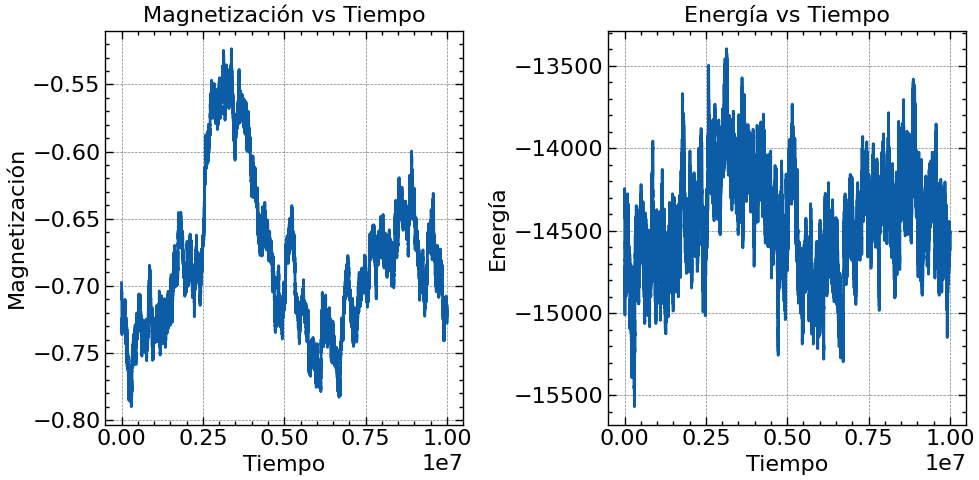

In [3]:
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(magnetizations)
plt.title('Magnetización vs Tiempo')
plt.xlabel('Tiempo')
plt.ylabel('Magnetización')

plt.subplot(1, 2, 2)
plt.plot(energies)
plt.title('Energía vs Tiempo')
plt.xlabel('Tiempo')
plt.ylabel('Energía')

plt.tight_layout()
plt.show()

# 🔹 Cumulante de Binder en el modelo de Ising 2D

El **cumulante de Binder** mide la **forma de la distribución de la magnetización**.

En cada temperatura, a partir de la serie temporal de magnetización por espín \( m_t = M_t / N \), se calculan los momentos estadísticos:

$$
\langle m^2 \rangle = \frac{1}{n}\sum_t m_t^2, \qquad
\langle m^4 \rangle = \frac{1}{n}\sum_t m_t^4.
$$

El **cumulante reducido de cuarto orden** se define como:

$$
U_4(T, L) = 1 - \frac{\langle m^4 \rangle}{3\,\langle m^2 \rangle^2}.
$$

---

## Interpretación física

- **Temperaturas bajas** (\(T < T_c\)):  
  El sistema está magnetizado, la distribución \(P(m)\) es **bimodal** (dos picos en ±m₀).  
  $$U_4 \approx \frac{2}{3} \approx 0.666.$$

- **Temperaturas altas** (\(T > T_c\)):  
  El sistema está desordenado, \(P(m)\) es **gaussiana** centrada en 0.  
  $$\langle m^4 \rangle = 3 \langle m^2 \rangle^2 \Rightarrow U_4 \approx 0.$$

- **Cerca de \(T_c\)**:  
  La distribución cambia de bimodal a unimodal →  
  \(U_4(T, L)\) **decrece suavemente** entre 2/3 y 0.

---

## Cómo se usa para estimar \(T_c\)

1. Simula varias redes con diferentes tamaños \(L\) (por ejemplo 16, 32, 64, 128).  
2. Calcula \(U_4(T, L)\) para un rango de temperaturas \(T\).  
3. Grafica \(U_4(T, L)\) vs \(T\).

El **punto de cruce** de las curvas para distintos tamaños \(L\) marca el **punto crítico \(T_c\)** en el límite termodinámico.

Este método es **adimensional** y **no requiere calibración** de magnitudes extensivas, por lo que es muy robusto.


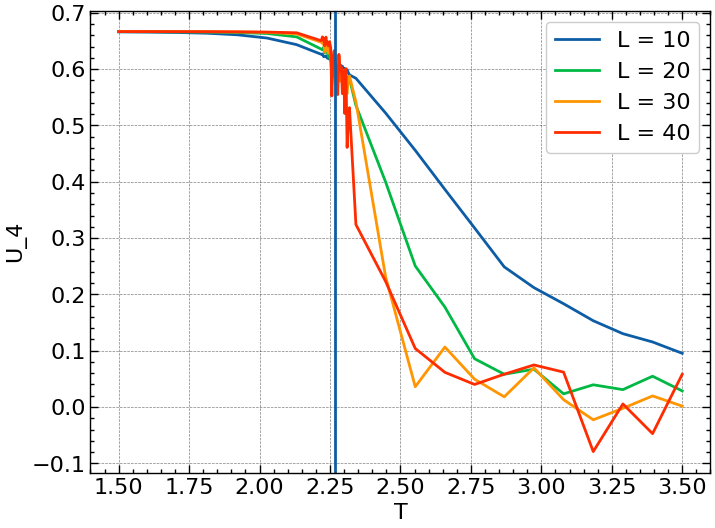

In [4]:
Tc = 2.269185314213
T_coarse = np.linspace(1.5, 3.5, 20)
T_fine = np.linspace(Tc - 0.05, Tc + 0.05, 25)
T_list = np.unique(np.concatenate([T_coarse, T_fine]))

# for L in ['256', '128', '64', '32', '16']:
for L in ['10', '20', '30', '40']:
    magnetizations = np.load('ising/U_4_'+L+'.npy')
    plt.plot(T_list, magnetizations, label = 'L = '+L)
plt.axvline(x = 2.269)
plt.xlabel('T')
# plt.ylim(0,0.7)
# plt.xlim(2.25,2.3)
plt.ylabel('U_4')
plt.legend()
plt.show()

# KURAMOTO

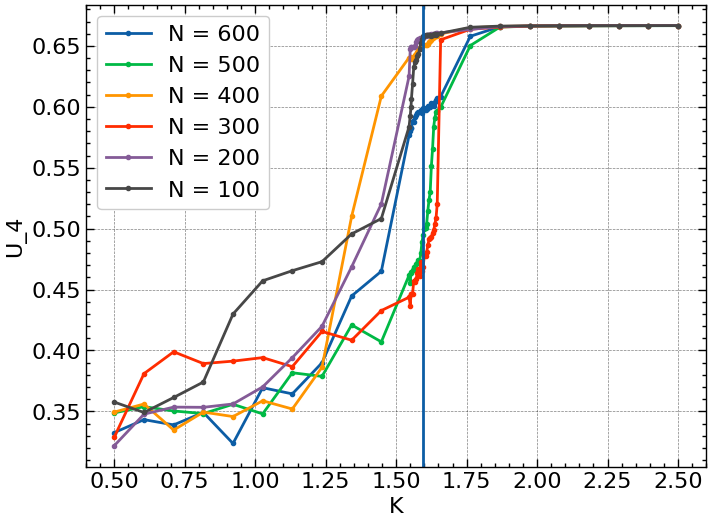

In [5]:
Kc = 2 * 1 * np.sqrt(2/np.pi)  # umbral teórico para g(ω) ~ N(0, σ^2)
T_coarse = np.linspace(0.5, 2.5, 20)
T_fine = np.linspace(Kc - 0.05, Kc + 0.05, 25)
T_list = np.unique(np.concatenate([T_coarse, T_fine]))

# for L in ['256', '128', '64', '32', '16']:
# for L in ['10', '20', '30', '40']:
for L in ['600','500', '400', '300', '200', '100']:
    magnetizations = np.load('kuramoto/U_4_'+L+'.npy')
    plt.plot(T_list, magnetizations, label = 'N = '+L, marker='.')
plt.axvline(x = Kc)
plt.xlabel('K')
# plt.ylim(0,0.7)
# plt.xlim(2.25,2.3)
plt.ylabel('U_4')
plt.legend()
plt.show()

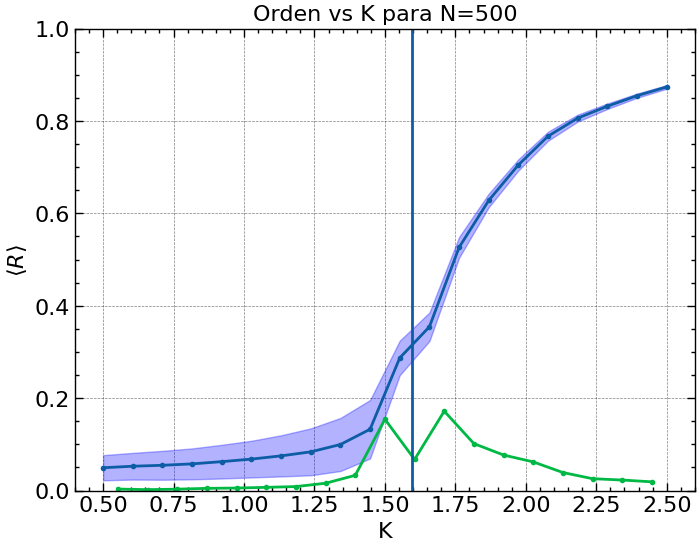

In [17]:
Kc = 2 * 1 * np.sqrt(2/np.pi)  # umbral teórico para g(ω) ~ N(0, σ^2)
T_coarse = np.linspace(0.5, 2.5, 20)
T_fine = np.linspace(Kc - 0.05, Kc + 0.05, 25)
T_list = np.unique(np.concatenate([T_coarse, T_fine]))
y = np.load('kuramoto/R_mean_N500.npy')
std = np.load('kuramoto/R_std_N500.npy')


n_puntos = len(T_coarse)
T_uniform = np.linspace(T_list.min(), T_list.max(), n_puntos)

# Interpola y(T) al nuevo eje uniforme
y = np.interp(T_uniform, T_list, y)
std = np.interp(T_uniform, T_list, std)
T_list = T_uniform

plt.plot(T_list, y, marker='.')
plt.fill_between(T_list, y - std, y + std, color='blue', alpha=0.3, label='±1σ')
plt.plot(T_list[:-1] + np.mean(np.abs(np.diff(T_list)))/2, np.diff(y), marker='.')
plt.xlabel('K')
plt.ylim(0,1)
plt.ylabel(r'$\langle R \rangle$')
plt.axvline(x = Kc)
plt.title('Orden vs K para N=500')
plt.show()

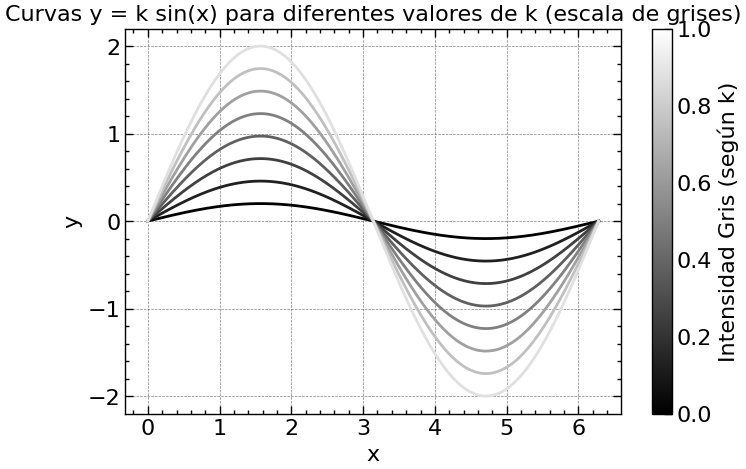

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


k_values = np.linspace(0.5, 2.5, 20)

cmap = plt.get_cmap('gray')

fig, ax = plt.subplots(figsize=(8, 5))

for i, k in enumerate(k_values):
    y = np.load(f'kuramoto/R_values/R_{k}.npy')[:4000]
    color = cmap(i / len(k_values))
    ax.plot(y, color=color, label=f'k = {k:.2f}')

ax.set_xlabel('t')
ax.set_ylabel('R(t)')
ax.grid(True)

# Crear un mappable para la barra de color
sm = plt.cm.ScalarMappable(cmap=cmap)
sm.set_array([])  # requerido para evitar el ValueError

# Agregar colorbar referida al ax
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Intensidad Gris (según k)')

plt.show()
